## Improved Models for 4h and 4h time horizons

### Import Libraries

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)



### Load Data and data checks

In [2]:
flights_4h = pd.read_csv("combined_data_4h.csv")
print("4h dataset shape:", flights_4h.shape)
flights_4h.head()

4h dataset shape: (339996, 32)


,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,5.0,69.0,1012.9,16.0,1,5.6,134.666667,30.746273,3.0,0.0
1,2022-01-01,2022-01-01 05:55:00,2022-01-01 05:52:00,DL,SLC,118.0,2022.0,1.0,5.0,1,...,5.0,69.0,1012.9,3.0,1,5.6,136.250000,24.931573,4.0,-3.0
2,2022-01-01,2022-01-01 06:00:00,2022-01-01 06:14:00,DL,ATL,272.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,20.0,1,5.6,136.250000,24.931573,4.0,14.0
3,2022-01-01,2022-01-01 06:02:00,2022-01-01 05:56:00,UA,LAX,98.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,6.0,1,5.6,141.666667,27.501515,3.0,-6.0
4,2022-01-01,2022-01-01 06:10:00,2022-01-01 07:51:00,DL,MSP,218.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,24.0,1,5.6,149.000000,26.820390,4.0,101.0


In [3]:
flights_4h.info()
flights_4h["outcome"].value_counts(
    dropna=False
).sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339996 entries, 0 to 339995
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   date                            339996 non-null  object 
 1   scheduled_dep_dt                339996 non-null  object 
 2   actual_dep_dt                   339996 non-null  object 
 3   carrier_code                    339996 non-null  object 
 4   destination_airport             339996 non-null  object 
 5   scheduled_elapsed_time_minutes  339996 non-null  float64
 6   year                            339996 non-null  float64
 7   month                           339996 non-null  float64
 8   day_of_week                     339996 non-null  float64
 9   is_weekend                      339996 non-null  int64  
 10  sched_dep_hour                  339996 non-null  float64
 11  outcome                         339996 non-null  float64
 12  days_until_holid

outcome
0.0    208369
1.0    109410
2.0     13473
3.0      4377
4.0      1692
5.0       768
6.0       410
7.0       581
8.0       916
Name: count, dtype: int64

In [4]:
#converting date column to datetime
flights_4h["date"] = pd.to_datetime(flights_4h["date"], errors="coerce")

In [5]:
#Chronological sort
flights_4h = (flights_4h 
    .sort_values("date")
    .reset_index(drop=True))

In [6]:
#Verifying the sort
print("Earliest date:", flights_4h["date"].min())
print("Latest date:", flights_4h["date"].max())

Earliest date: 2022-01-01 00:00:00
Latest date: 2026-04-30 00:00:00


In [7]:
#verifying target and converting outcomes to integer
flights_4h["outcome"] = flights_4h["outcome"].astype(int)

print("Target datatype:", flights_4h["outcome"].dtype)

print("Missing target values:", flights_4h["outcome"].isna().sum())

print("Outcome classes:", sorted(flights_4h["outcome"].dropna().unique()))

Target datatype: int64
Missing target values: 0
Outcome classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]


### Feature Selection

In [8]:
#feature selection
numeric_features_4h = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h"
]

In [9]:
categorical_features_4h = [
    "carrier_code",
    "destination_airport",
    "model"
]

In [10]:
features_4h = (numeric_features_4h + categorical_features_4h)
target_4h = "outcome"

In [11]:
#verifying columns exist
missing_features_4h = [
    column
    for column in features_4h
    if column not in flights_4h.columns]
print("Missing features:", missing_features_4h)

Missing features: []


### Data Splits

In [12]:
train_4h = flights_4h[flights_4h["date"] < "2024-01-01"].copy()

validation_4h = flights_4h[(flights_4h["date"] >= "2024-01-01") & (flights_4h["date"] < "2025-01-01")].copy()

test_4h = flights_4h[flights_4h["date"] >= "2025-01-01"].copy()

In [13]:
print("4h training rows:", len(train_4h))
print("4h validation rows:", len(validation_4h))
print("4h test rows:", len(test_4h))

4h training rows: 154285
4h validation rows: 86039
4h test rows: 99672


In [14]:
#verifying data ranges
print("Train:", train_4h["date"].min(), "-", train_4h["date"].max())

print(
    "Validation:", validation_4h["date"].min(), "-", validation_4h["date"].max())

print("Test:", test_4h["date"].min(), "-", test_4h["date"].max())

Train: 2022-01-01 00:00:00 - 2023-12-31 00:00:00
Validation: 2024-01-01 00:00:00 - 2024-12-31 00:00:00
Test: 2025-01-01 00:00:00 - 2026-04-30 00:00:00


### Defining the input and output features

In [15]:
X_train_4h = train_4h[features_4h].copy()
y_train_4h = train_4h[target_4h].copy()

X_validation_4h = validation_4h[features_4h].copy()
y_validation_4h = validation_4h[target_4h].copy()

X_test_4h = test_4h[features_4h].copy()
y_test_4h = test_4h[target_4h].copy()

### preprocessing


In [16]:
numeric_transformer_4h = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

In [17]:
categorical_transformer_4h = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))])

In [18]:
preprocessor_4h = ColumnTransformer([("numeric", numeric_transformer_4h, numeric_features_4h), ("categorical", categorical_transformer_4h, categorical_features_4h)])

In [19]:
#only fitting on training data
X_train_4h_processed = (preprocessor_4h.fit_transform(X_train_4h))

X_validation_4h_processed = (preprocessor_4h.transform(X_validation_4h))

X_test_4h_processed = (preprocessor_4h.transform(X_test_4h))

/Users/anushkagadodia/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anushkagadodia/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [20]:
print("Processed training shape:", X_train_4h_processed.shape)
print("Processed validation shape:", X_validation_4h_processed.shape)
print("Processed test shape:", X_test_4h_processed.shape)

Processed training shape: (154285, 170)
Processed validation shape: (86039, 170)
Processed test shape: (99672, 170)


### Random Forest Classifier for 4h dataset

In [21]:
rf_model_4h = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)

In [22]:
#training the model
rf_model_4h.fit(X_train_4h_processed, y_train_4h)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [23]:
#predictions!!
train_predictions_4h = rf_model_4h.predict(X_train_4h_processed)
validation_predictions_4h = rf_model_4h.predict(X_validation_4h_processed)
test_predictions_4h = rf_model_4h.predict(X_test_4h_processed)

In [24]:
#train, val, and test accuract
train_accuracy_4h = accuracy_score(y_train_4h, train_predictions_4h)
validation_accuracy_4h = accuracy_score(y_validation_4h, validation_predictions_4h)
test_accuracy_4h = accuracy_score(y_test_4h,test_predictions_4h)

print(f"2-Hour Training Accuracy: {train_accuracy_4h}")
print(f"2-Hour Validation Accuracy: {validation_accuracy_4h}")
print(f"2-Hour Test Accuracy: {test_accuracy_4h}")

print("Training-validation difference:", abs(train_accuracy_4h - validation_accuracy_4h))

2-Hour Training Accuracy: 0.7845351135884888
2-Hour Validation Accuracy: 0.5686491009890864
2-Hour Test Accuracy: 0.5700898948551248
Training-validation difference: 0.21588601259940243


In [25]:
validation_balanced_accuracy_4h = (balanced_accuracy_score(y_validation_4h, validation_predictions_4h))
test_balanced_accuracy_4h = (balanced_accuracy_score(y_test_4h, test_predictions_4h))

print("2-Hour Validation Balanced Accuracy:", validation_balanced_accuracy_4h)
print("2-Hour Test Balanced Accuracy:", test_balanced_accuracy_4h)

2-Hour Validation Balanced Accuracy: 0.14092912700494237
2-Hour Test Balanced Accuracy: 0.14235774202142654


In [26]:
#Classification
class_labels = [
    "No delay / Early",
    "< 1 hour",
    "1–2 hours",
    "2–3 hours",
    "3–4 hours",
    "4–5 hours",
    "5–6 hours",
    "> 6 hours",
    "Cancelled"
]

In [27]:
print(classification_report(
        y_test_4h,
        test_predictions_4h,
        labels=list(range(9)),
        target_names=class_labels,
        zero_division=0))

                  precision    recall  f1-score   support

No delay / Early       0.74      0.62      0.68     63797
        < 1 hour       0.39      0.57      0.46     29166
       1–2 hours       0.09      0.07      0.08      4006
       2–3 hours       0.06      0.00      0.01      1354
       3–4 hours       0.00      0.00      0.00       527
       4–5 hours       0.00      0.00      0.00       251
       5–6 hours       0.00      0.00      0.00       110
       > 6 hours       0.09      0.01      0.01       161
       Cancelled       0.08      0.00      0.01       300

        accuracy                           0.57     99672
       macro avg       0.16      0.14      0.14     99672
    weighted avg       0.59      0.57      0.57     99672



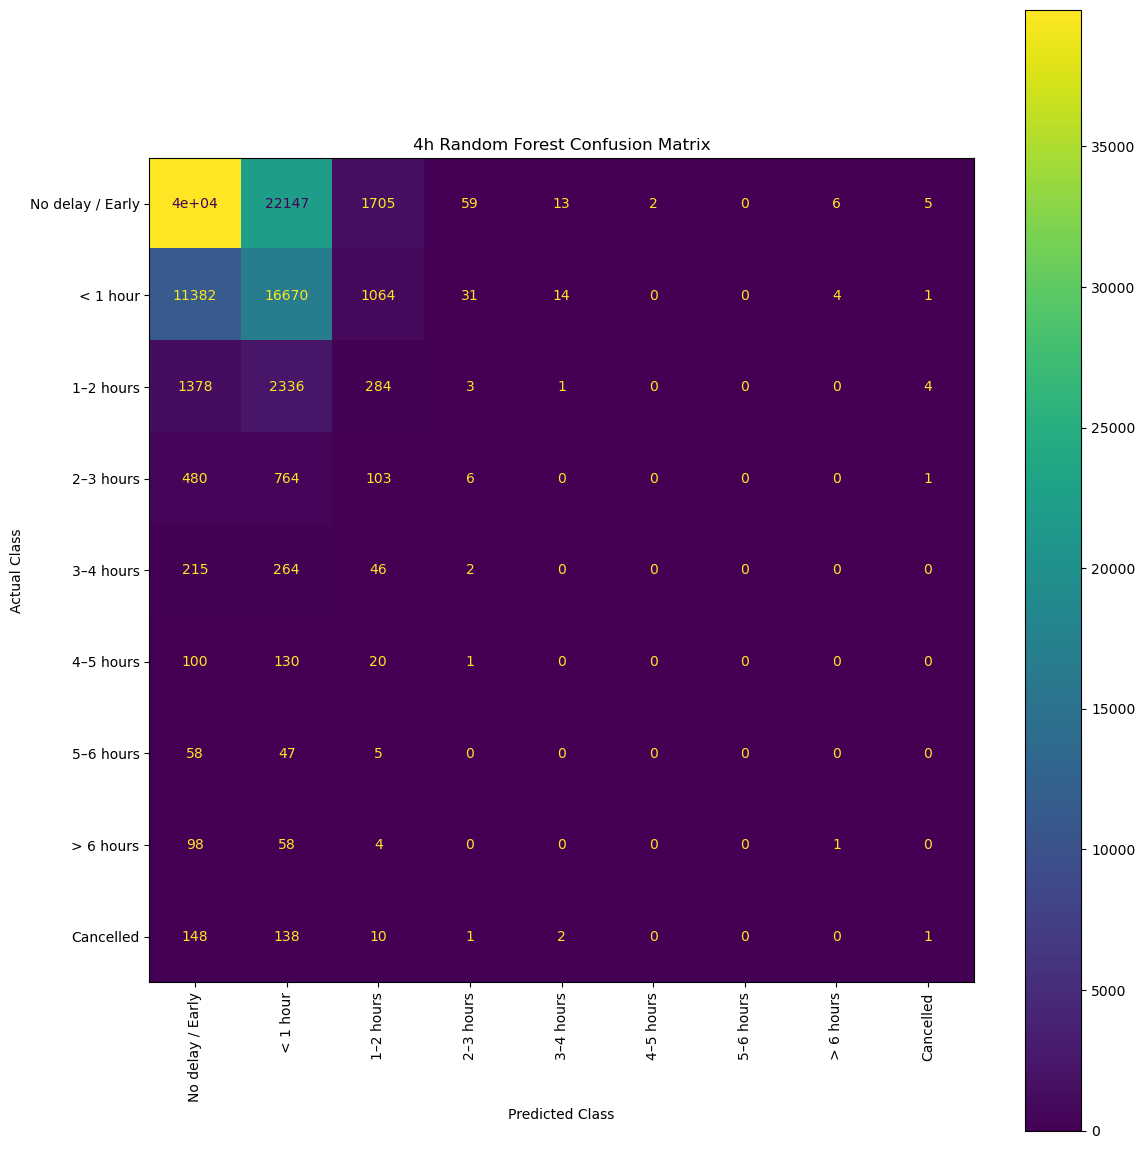

In [28]:
fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test_4h,
    test_predictions_4h,
    labels=list(range(9)),
    display_labels=class_labels,
    xticks_rotation=90,
    ax=ax)

plt.title("4h Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()